<a href="https://colab.research.google.com/github/Mauricio8583/Google-Colab-Files/blob/main/amea%C3%A7as.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

(10000, 16)
['ip_address', 'abuse_confidence_score', 'country_code', 'last_reported_at', 'country_name', 'continent', 'reported_date', 'reported_year', 'reported_month', 'reported_day', 'reported_hour', 'reported_weekday', 'label', 'risk_level', 'severity', 'time_zone_attack']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   ip_address              10000 non-null  object
 1   abuse_confidence_score  10000 non-null  int64 
 2   country_code            10000 non-null  object
 3   last_reported_at        10000 non-null  object
 4   country_name            10000 non-null  object
 5   continent               10000 non-null  object
 6   reported_date           10000 non-null  object
 7   reported_year           10000 non-null  int64 
 8   reported_month          10000 non-null  int64 
 9   reported_day            10000 non-nul

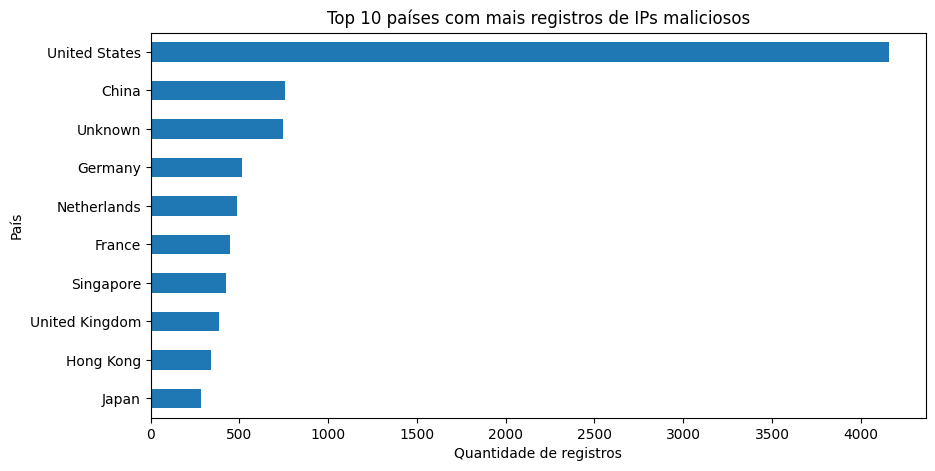

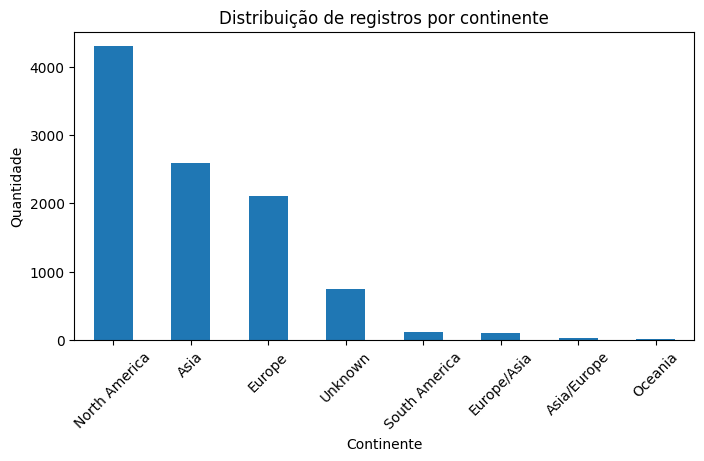

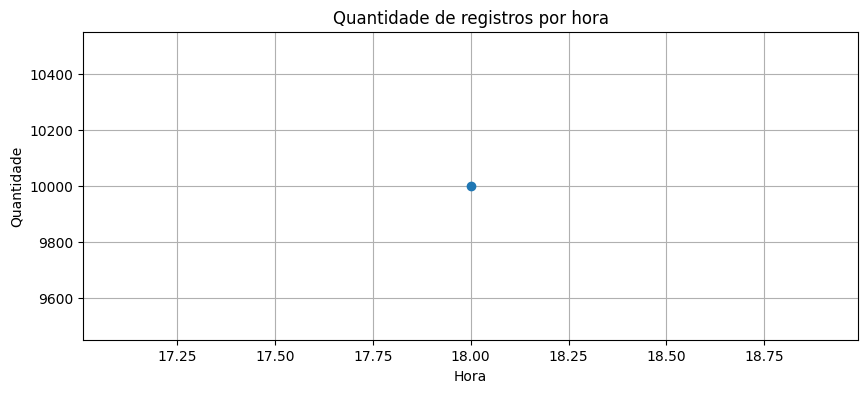

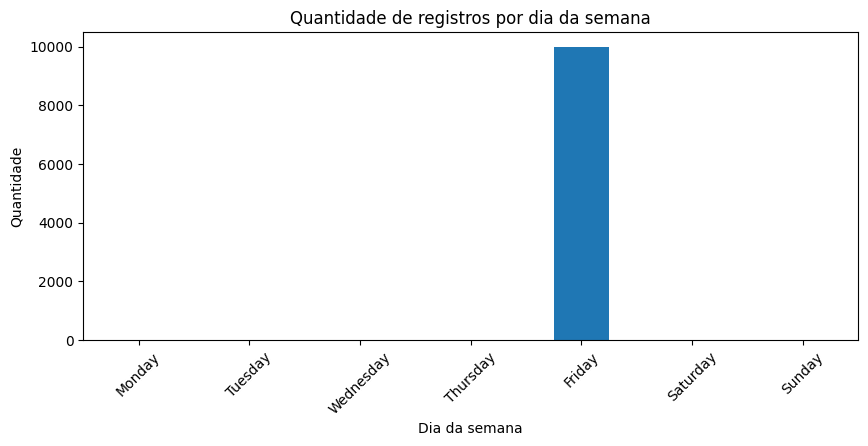

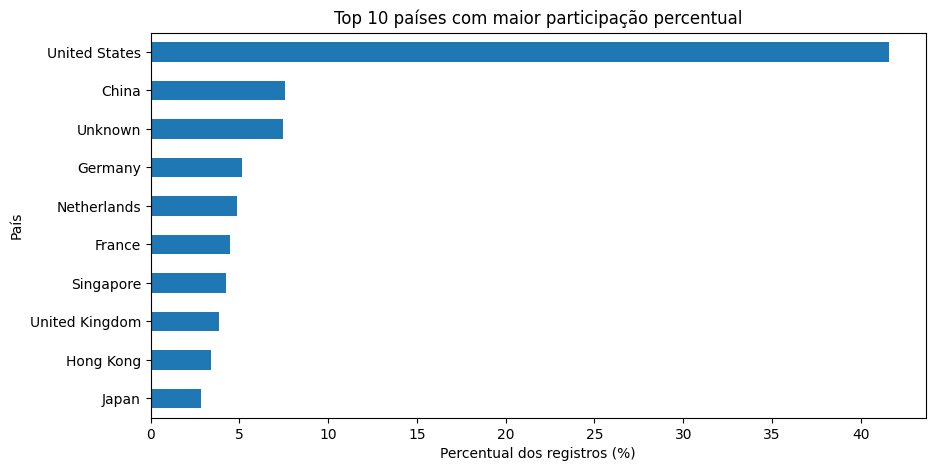

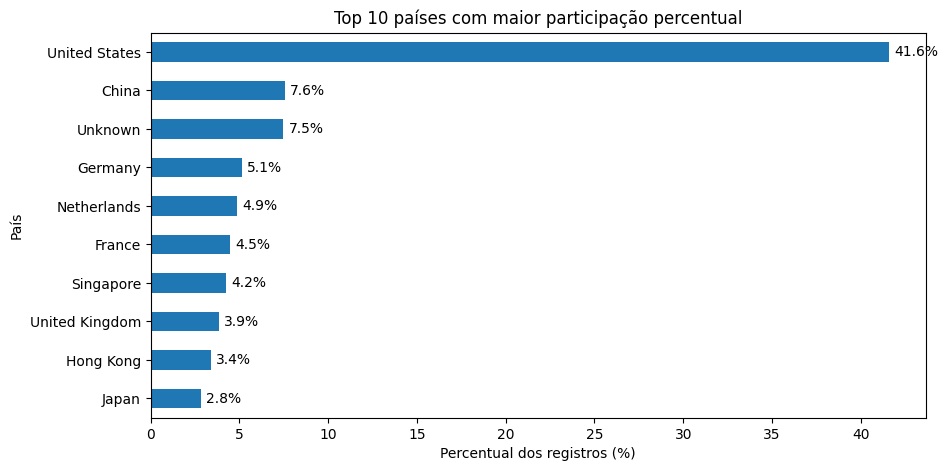

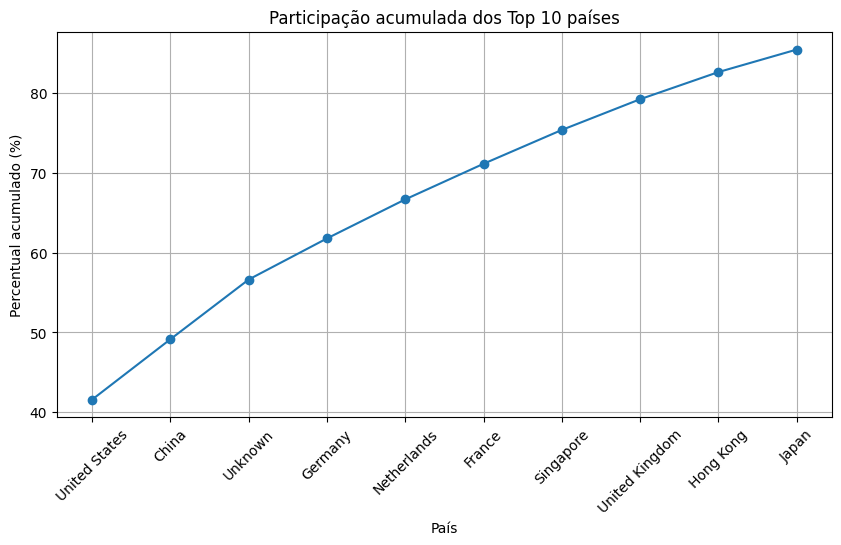

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('final_kaggle_cyber_dataset.csv')
df.head()

# Preparação dos dados
print(df.shape)
print(df.columns.to_list())
df.info()
print(df.isnull().sum())

# Conversão dos dados de las_reported_date
df['last_reported_at'] = pd.to_datetime(df['last_reported_at'], errors='coerce')
df['reported_date'] = pd.to_datetime(df['reported_date'], errors='coerce')
print(df[['last_reported_at', 'reported_date']])

# Registros únicos
print("Total de Registros: ", len(df))
print("Ips únicos:", df['ip_address'].nunique())
print("Países únicos:", df['country_name'].nunique())
print("Continentes únicos:", df['continent'].nunique())

top_countries = df['country_name'].value_counts().head(10)

plt.figure(figsize=(10, 5))
top_countries.sort_values().plot(kind='barh')
plt.title('Top 10 países com mais registros de IPs maliciosos')
plt.xlabel('Quantidade de registros')
plt.ylabel('País')
plt.show()

plt.figure(figsize=(8,4))
df['continent'].value_counts().plot(kind='bar')
plt.title('Distribuição de registros por continente')
plt.xlabel('Continente')
plt.ylabel('Quantidade')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10,4))
df['reported_hour'].value_counts().sort_index().plot(kind='line', marker='o')
plt.title('Quantidade de registros por hora')
plt.xlabel('Hora')
plt.ylabel('Quantidade')
plt.grid(True)
plt.show()

ordem_dias = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_counts = df['reported_weekday'].value_counts().reindex(ordem_dias)

plt.figure(figsize=(10,4))
weekday_counts.plot(kind='bar')
plt.title('Quantidade de registros por dia da semana')
plt.xlabel('Dia da semana')
plt.ylabel('Quantidade')
plt.xticks(rotation=45)
plt.show()

top10_pct = (df['country_name'].value_counts(normalize=True).head(10) * 100).sort_values()

plt.figure(figsize=(10,5))
top10_pct.plot(kind='barh')
plt.title('Top 10 países com maior participação percentual')
plt.xlabel('Percentual dos registros (%)')
plt.ylabel('País')
plt.show()

top10_pct = (df['country_name'].value_counts(normalize=True).head(10) * 100).sort_values()

plt.figure(figsize=(10,5))
ax = top10_pct.plot(kind='barh')

for i, v in enumerate(top10_pct.values):
    ax.text(v + 0.3, i, f'{v:.1f}%', va='center')

plt.title('Top 10 países com maior participação percentual')
plt.xlabel('Percentual dos registros (%)')
plt.ylabel('País')
plt.show()


country_pct = (df['country_name'].value_counts(normalize=True) * 100).head(10)
country_cumsum = country_pct.cumsum()

plt.figure(figsize=(10,5))
plt.plot(range(1, len(country_cumsum)+1), country_cumsum.values, marker='o')
plt.xticks(range(1, len(country_cumsum)+1), country_pct.index, rotation=45)
plt.title('Participação acumulada dos Top 10 países')
plt.xlabel('País')
plt.ylabel('Percentual acumulado (%)')
plt.grid(True)
plt.show()